# Figure 3 - Bayesian observer model parameters

Per-subject maximum-likelihood fits by group: measurement noise $w_m$ (A), motor noise $w_r$ (B), and multiplicative gain $\alpha$ (C).

Reads `data/fig_subject_level.csv` (run `fit_all_subjects.py` first) and saves `results/figures/Figure3.{pdf,png}`.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / "mstiming").exists() else _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mstiming import config, plotting, stats

font = plotting.publication_style()
for pth, script in [(config.FIG_SUBJECT_LEVEL_CSV, "fit_all_subjects.py")]:
    if not pth.exists():
        raise FileNotFoundError(f"Missing {pth.name} -- run: python run_fits/{script}")

df_sub = pd.read_csv(config.FIG_SUBJECT_LEVEL_CSV)
df_sub["Group"] = pd.Categorical(df_sub["Group"], ["Control", "MS"])
print(f"font={font} | N Control={(df_sub.Group=='Control').sum()} N MS={(df_sub.Group=='MS').sum()}")


font=Gill Sans | N Control=140 N MS=79


## Group comparison statistics

In [2]:
# Model-parameter comparisons (Control vs MS) for the three panels.
P = {}
for v in ["timeWm_BLS_Mod", "timeWp_BLS_Mod", "timeAlpha_BLS"]:
    p, test = stats.adaptive_test(df_sub.loc[df_sub.Group == "Control", v],
                                  df_sub.loc[df_sub.Group == "MS", v])
    P[v] = p
    print(f"{v:16s}: p = {p:.4f}  [{test}]")


timeWm_BLS_Mod  : p = 0.0076  [Mann-Whitney]
timeWp_BLS_Mod  : p = 0.6853  [Mann-Whitney]
timeAlpha_BLS   : p = 0.7976  [Mann-Whitney]


## Figure

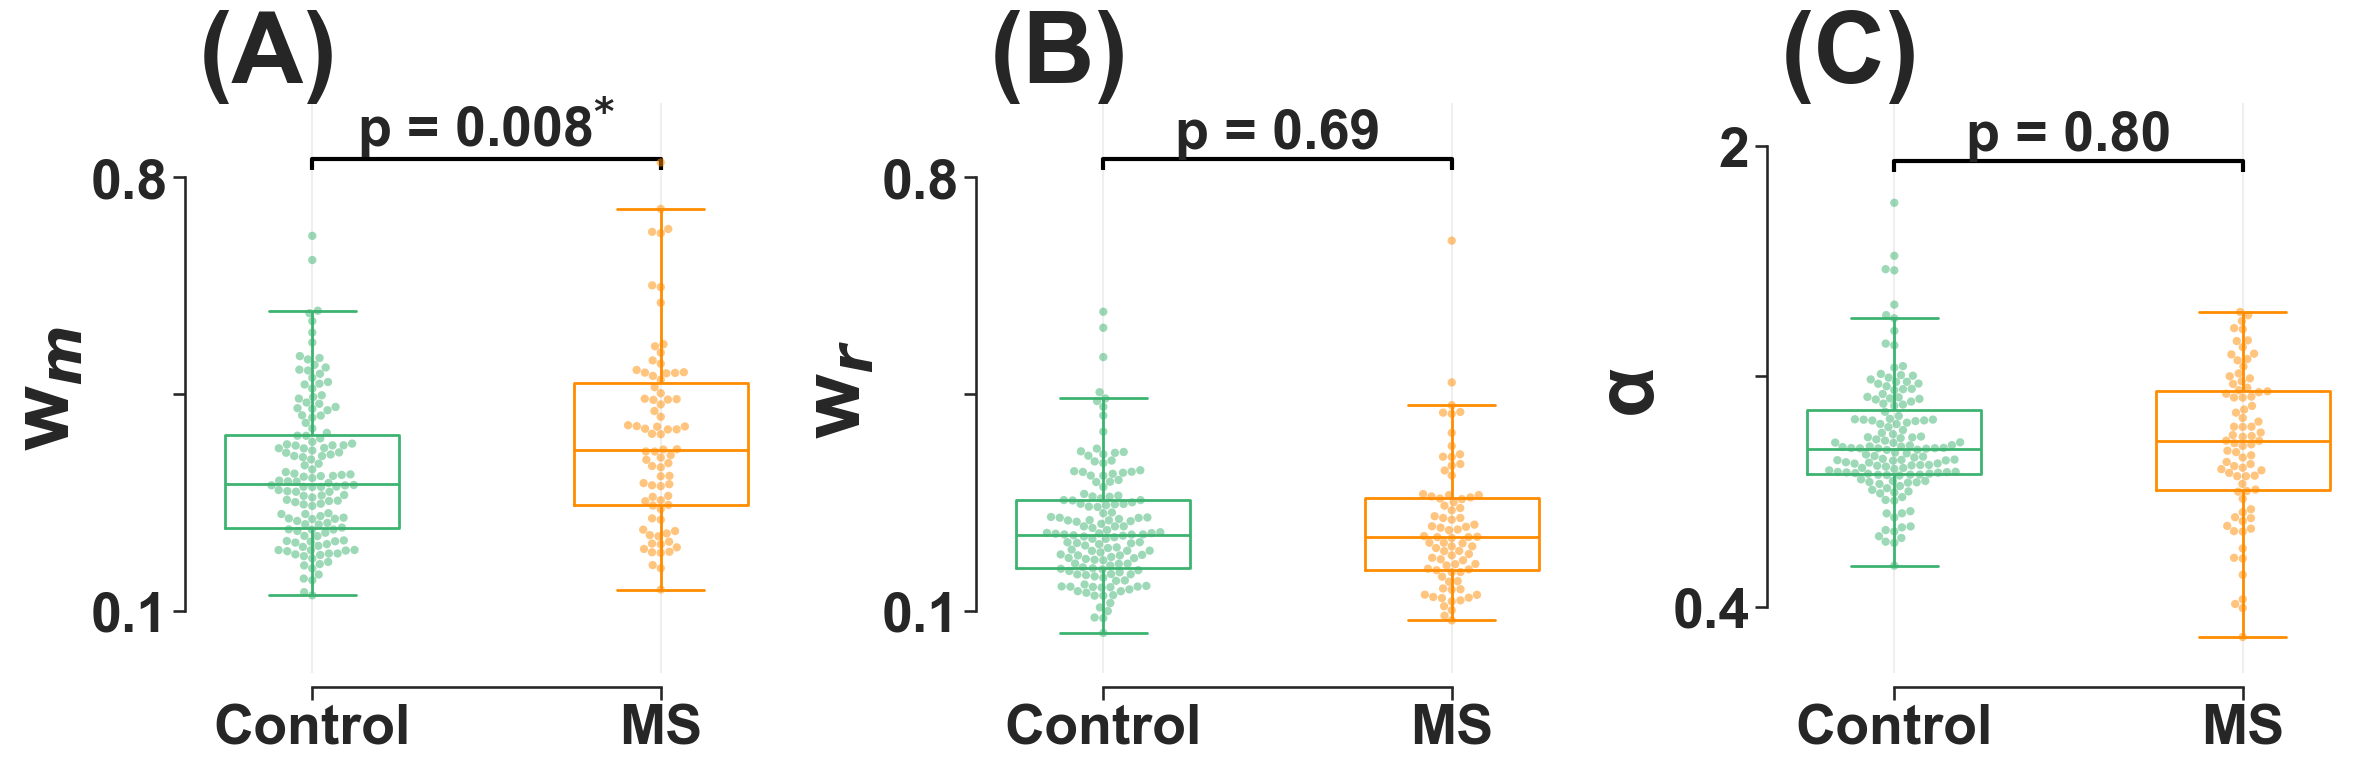

In [3]:
fig, ax = plt.subplots(1, 3, sharey=False); fig.set_figheight(8); fig.set_figwidth(24)

# (A) w_m
plotting.box_swarm(ax[0], df_sub, "timeWm_BLS_Mod")
ax[0].set_title('(A)', fontsize=72, loc='left', fontweight='bold')
ax[0].set_xlabel(''); ax[0].set_ylabel(r'w$_{m}$', fontsize=60); ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([0.1, 0.45, 0.8]); ax[0].set_yticklabels([0.1, None, 0.8], fontsize=40)
ax[0].tick_params(axis='x', labelsize=40); ax[0].tick_params(axis='y', labelsize=40)
ax[0].set_ylim(0, 0.92)
plotting.sig_bar(ax[0], 0, 1, 0.83, P["timeWm_BLS_Mod"], fontsize=40)

# (B) w_r
plotting.box_swarm(ax[1], df_sub, "timeWp_BLS_Mod")
ax[1].set_title('(B)', fontsize=72, loc='left', fontweight='bold')
ax[1].set_xlabel(''); ax[1].set_ylabel(r'w$_{r}$', fontsize=60); ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([0.1, 0.45, 0.8]); ax[1].set_yticklabels([0.1, None, 0.8], fontsize=40)
ax[1].tick_params(axis='x', labelsize=40); ax[1].tick_params(axis='y', labelsize=40)
ax[1].set_ylim(0, 0.92)
plotting.sig_bar(ax[1], 0, 1, 0.83, P["timeWp_BLS_Mod"], fontsize=40)

# (C) alpha
plotting.box_swarm(ax[2], df_sub, "timeAlpha_BLS")
ax[2].set_title('(C)', fontsize=72, loc='left', fontweight='bold')
ax[2].set_xlabel(''); ax[2].set_ylabel('α', fontsize=60); ax[2].grid(axis='x', alpha=0.3)
ax[2].set_yticks([0.4, 1.2, 2]); ax[2].set_yticklabels([0.4, None, 2], fontsize=40)
ax[2].tick_params(axis='x', labelsize=40); ax[2].tick_params(axis='y', labelsize=40)
ax[2].set_ylim(0.17, 2.15)
plotting.sig_bar(ax[2], 0, 1, 1.95, P["timeAlpha_BLS"], fontsize=40)

sns.despine(offset=10, trim=True)
plt.tight_layout()
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIG_DIR / "Figure3.png", dpi=300)
fig.savefig(config.FIG_DIR / "Figure3.pdf", format="pdf", bbox_inches="tight")
plt.show()
